### 1 . Importing Modules

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

### Importing DataSet

In [176]:
data = pd.read_csv("retail_demand.csv")

### First Five Rows

In [177]:
data.head()

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold
0,1,8222,Chennai,Summer,Heater,1849.0363,2117.0487,12
1,2,8222,Bangalore,Monsoon,Heater,1336.9121,1534.1589,26
2,3,8058,Kolkata,Winter,Heater,2320.4793,2631.3738,220
3,4,8091,Chennai,Winter,Raincoat,173.1042,202.8265,51
4,5,8512,Chennai,Autumn,Umbrella,244.9977,245.6155,77


# Data Preprocessing

## Shape of the Dataset

In [178]:
data.shape

(150150, 8)

## Descriptive statistics of the data-sets

In [179]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,150150.0,75075.500000,43344.715797,1.0000,37538.250000,75075.5000,112612.7500,150150.0000
Store ID,150150.0,8295.660346,262.577092,8023.0000,8091.000000,8218.0000,8512.0000,8856.0000
Total Price,150145.0,443.152466,526.007672,34.1819,115.964800,275.1850,500.9034,2989.8010
Base Price,150150.0,479.141370,567.839558,40.0020,125.206225,299.2251,541.5735,2999.9451
Units Sold,150150.0,106.588731,79.647093,9.0000,44.000000,78.0000,151.0000,390.0000


## Correlation between features in a dataset

In [180]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Location'] = le.fit_transform(data['Location'])
data['Season']   = le.fit_transform(data['Season'])
data['Product']  = le.fit_transform(data['Product'])
print(data.head())

   ID  Store ID  Location  Season  Product  Total Price  Base Price  \
0   1      8222         1       2        1    1849.0363   2117.0487   
1   2      8222         0       1        1    1336.9121   1534.1589   
2   3      8058         5       3        1    2320.4793   2631.3738   
3   4      8091         1       3        4     173.1042    202.8265   
4   5      8512         1       0        8     244.9977    245.6155   

   Units Sold  
0          12  
1          26  
2         220  
3          51  
4          77  


In [181]:
data.corr()

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold
ID,1.000000,0.002283,0.004907,-0.006164,-0.000551,-0.000605,-0.000531,0.000153
Store ID,0.002283,1.000000,0.000780,-0.000391,0.000554,0.002235,0.002384,0.005913
Location,0.004907,0.000780,1.000000,0.000061,-0.004101,-0.004748,-0.004599,-0.006194
Season,-0.006164,-0.000391,0.000061,1.000000,0.000198,-0.004217,-0.004120,0.046131
Product,-0.000551,0.000554,-0.004101,0.000198,1.000000,-0.300906,-0.301475,0.019428
Total Price,-0.000605,0.002235,-0.004748,-0.004217,-0.300906,1.000000,0.998122,-0.027540
Base Price,-0.000531,0.002384,-0.004599,-0.004120,-0.301475,0.998122,1.000000,-0.027590
Units Sold,0.000153,0.005913,-0.006194,0.046131,0.019428,-0.027540,-0.027590,1.000000


## Data types and more information about the data

In [182]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           150150 non-null  int64  
 1   Store ID     150150 non-null  int64  
 2   Location     150150 non-null  int32  
 3   Season       150150 non-null  int32  
 4   Product      150150 non-null  int32  
 5   Total Price  150145 non-null  float64
 6   Base Price   150150 non-null  float64
 7   Units Sold   150150 non-null  int64  
dtypes: float64(2), int32(3), int64(3)
memory usage: 7.4 MB


## Checking for Missing Values

In [183]:
#The Data Contains Missing values
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    5
Base Price     0
Units Sold     0
dtype: int64

In [184]:
S = pd.isnull(data['Total Price'])
data[S]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold
23891,23892,8091,7,0,9,NaN,145.5068,119
45231,45232,8222,5,2,8,NaN,223.1944,47
78456,78457,8218,5,3,4,NaN,403.9851,50
112034,112035,8401,0,2,5,NaN,79.3540,96
136949,136950,8121,4,2,1,NaN,1673.2009,20


In [185]:
import sys
!{sys.executable} -m pip install missingno

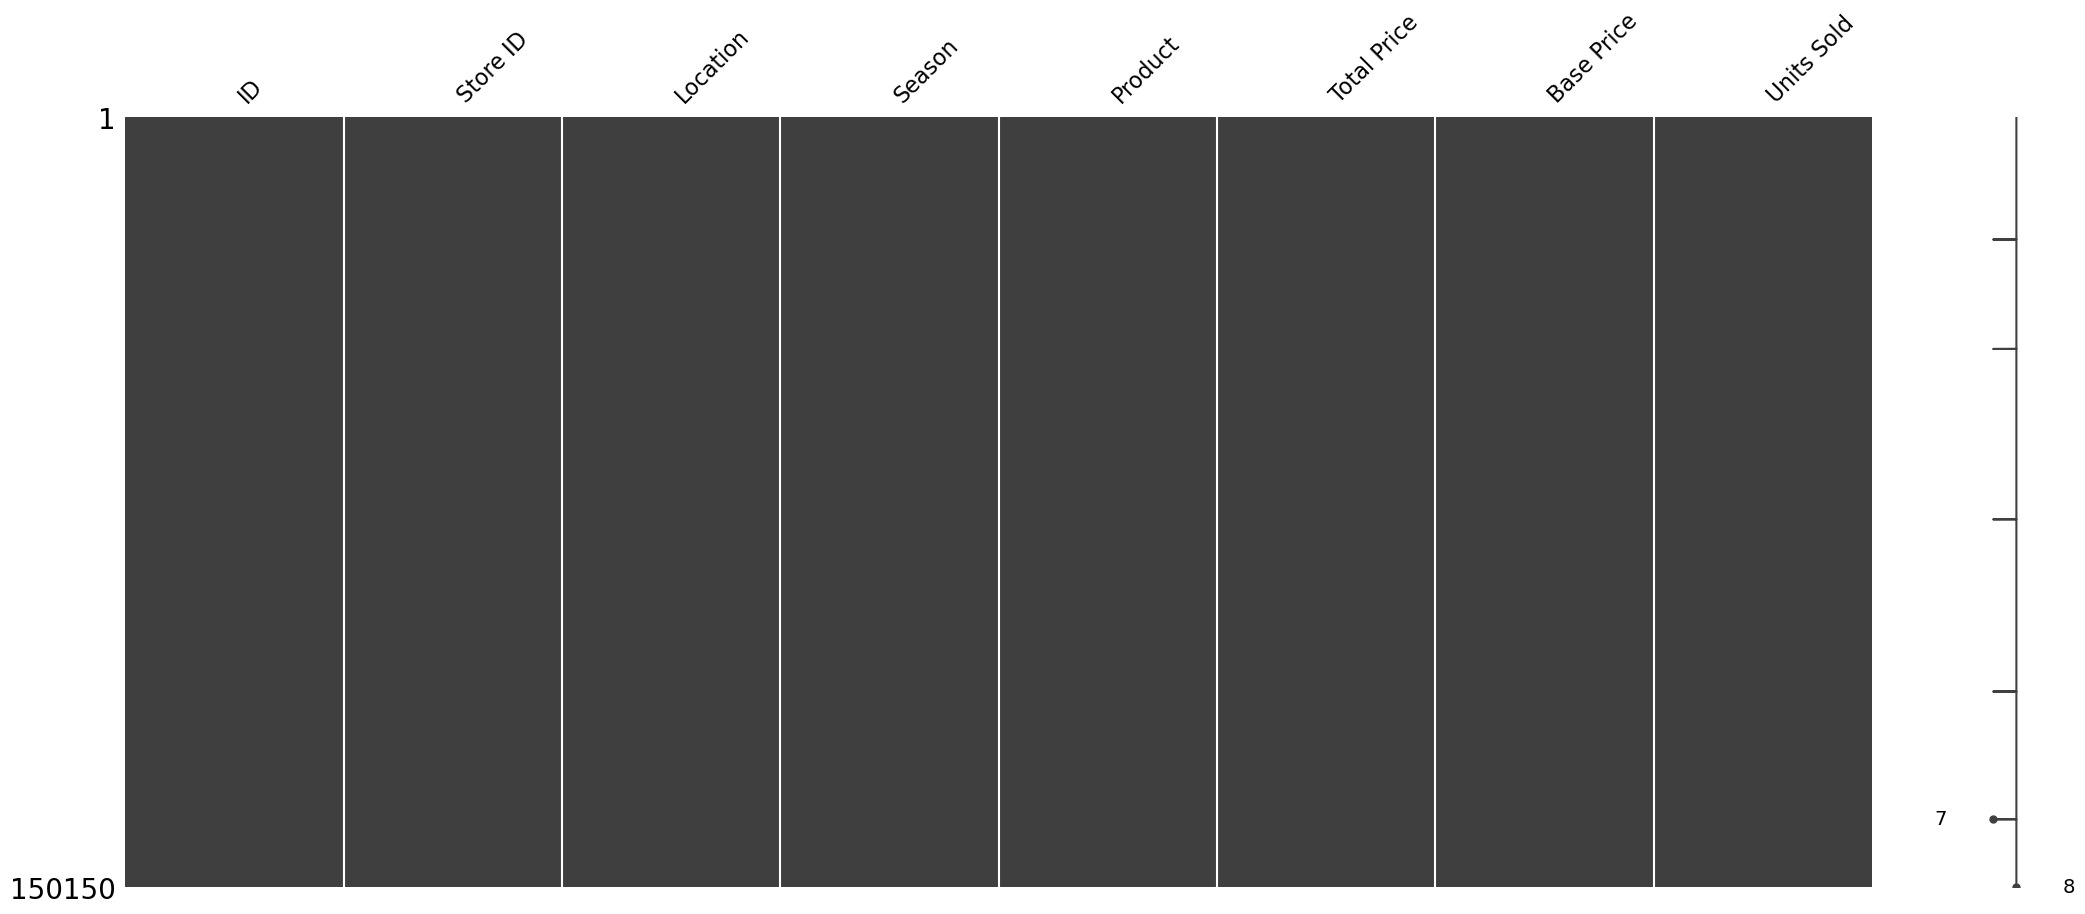

<Figure size 1000x600 with 0 Axes>

In [186]:
import missingno as msno 
msno.matrix(data)
plt.figure(figsize=(10,6))
plt.show()

<Axes: >

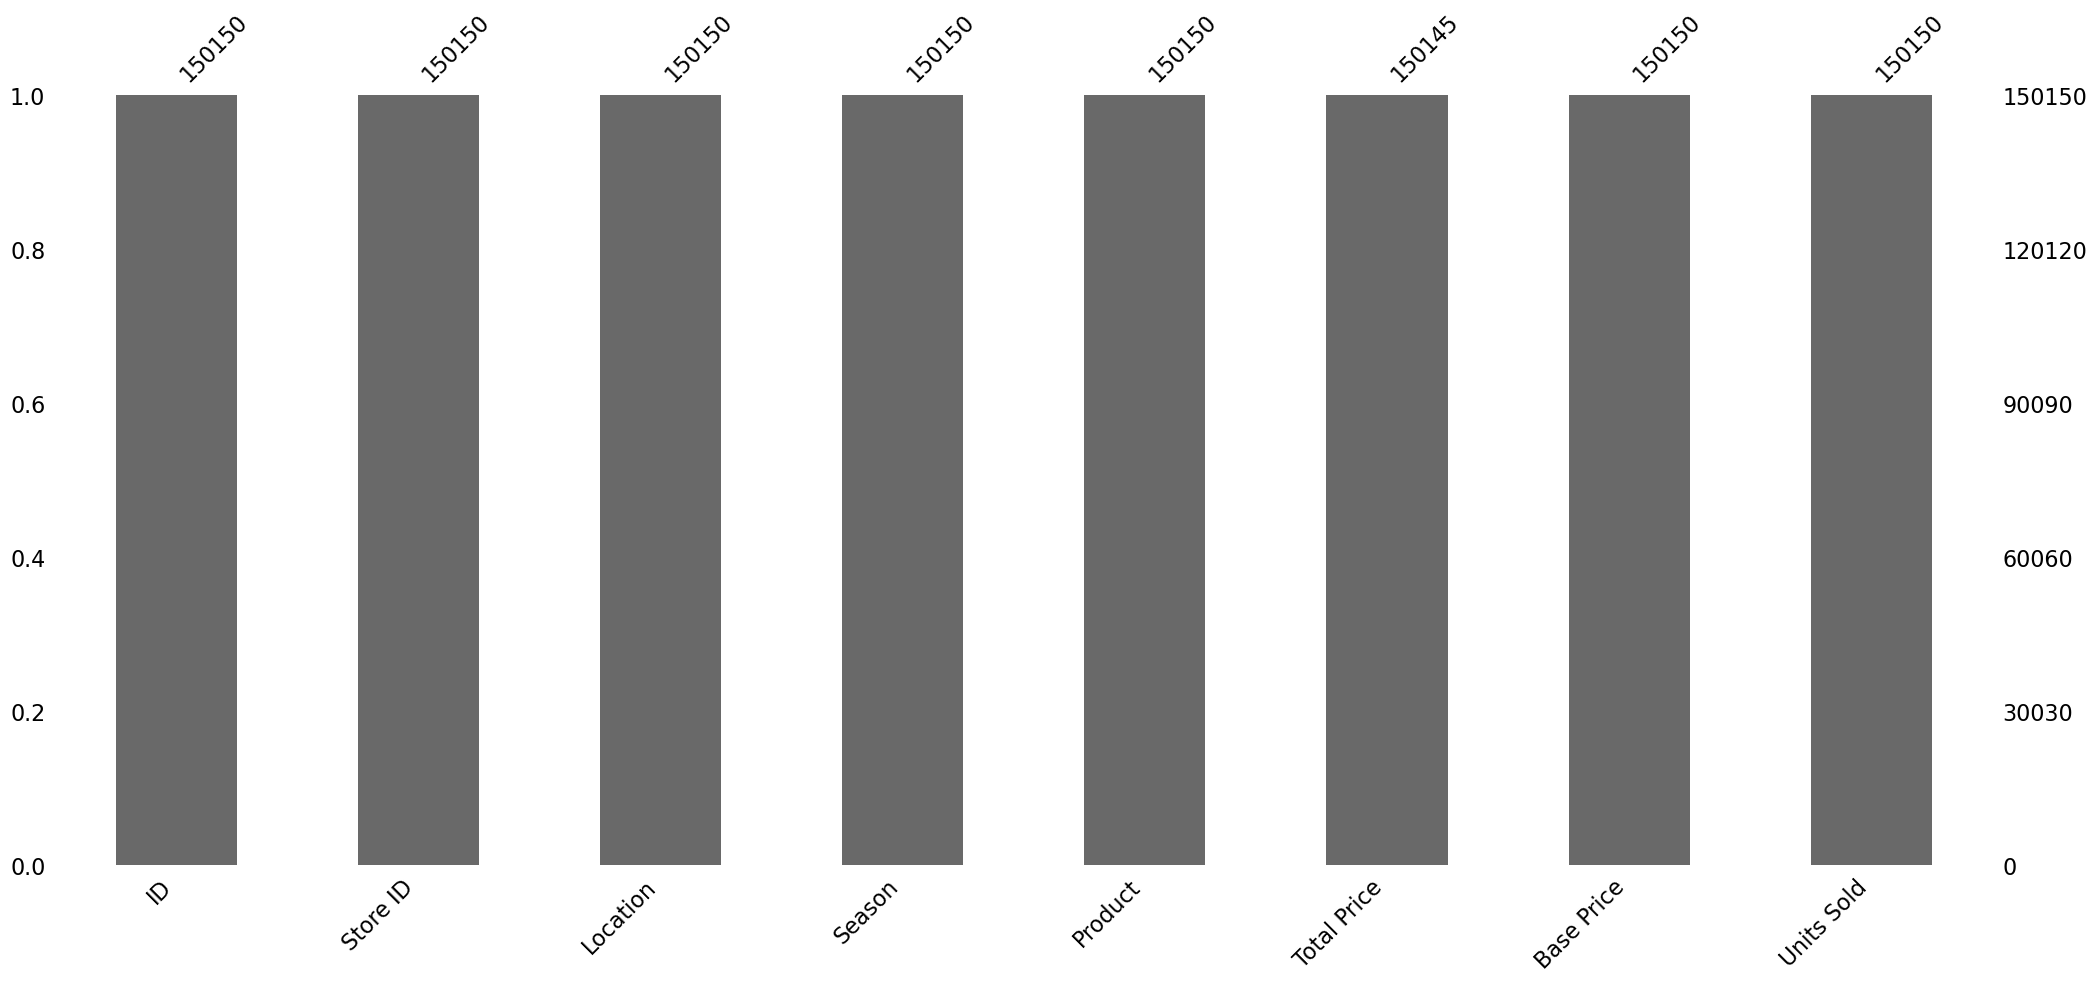

In [187]:
msno.bar(data)

## 1.Delete the missing value

In [188]:
data = data.dropna()

In [189]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Location'] = le.fit_transform(data['Location'])
data['Season']   = le.fit_transform(data['Season'])
data['Product']  = le.fit_transform(data['Product'])

In [190]:
data.shape

(150145, 8)

## 2.Replacing with an arbitrary value

In [191]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [192]:
data['Total Price'] = data['Total Price'].fillna(data['Base Price'])

In [193]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [194]:

data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 3.Replacing with the Mean

In [195]:

data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [196]:
data['Total Price'] = data['Total Price'].fillna(data['Base Price'].mean())

In [197]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [198]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 4.Replacing with the Mode

In [199]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [200]:
data['Total Price'] = data['Total Price'].fillna(data['Base Price'].mode()[0])

In [201]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [202]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 5.Replacing with the Median

In [203]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [204]:
data['Total Price'] = data['Total Price'].fillna(data['Base Price'].median())

In [205]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [206]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 6.Replacing with the Previous value – forward fill

In [207]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [208]:
data = data.ffill()


In [209]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [210]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 7.Replacing with the Next value – backward fill

In [211]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [212]:
data = data.bfill()

In [213]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [214]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 7.Interpolation

In [215]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [216]:
data = data.interpolate()

In [217]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [218]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


 ## 8.Multivariate Approach

### 8.1 Iterative Imputer

In [219]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [220]:
X = data[['Total Price','Base Price','Units Sold']]

In [221]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
impute_it = IterativeImputer()
impute_it.fit_transform(X)[136949]

array([183.3578, 191.6836,  76.    ])

### 8.2 KNN Imputer

In [222]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [223]:
X = data[['Total Price','Base Price','Units Sold']]

In [224]:
from sklearn.impute import KNNImputer
impute_knn = KNNImputer(n_neighbors=2)
impute_knn.fit_transform(X)[136949]

array([183.3578, 191.6836,  76.    ])

## Spliting the Data

In [225]:
# Define the features (X) and target variable (y)
X = data[['Store ID', 'Total Price', 'Base Price']]
y = data['Units Sold']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Features Scaling

### 1.Standardization

In [226]:
Std = preprocessing.StandardScaler()
X_train = Std.fit_transform(X_train)
X_test = Std.fit_transform(X_test)
X_train

array([[-0.27945055, -0.47806443, -0.4901406 ],
       [ 2.13542075, -0.46942725, -0.47228005],
       [-0.27945055,  0.53972443,  0.4894094 ],
       ...,
       [ 1.71262783,  0.14565074,  0.08725624],
       [ 0.40235065, -0.12832923, -0.15100515],
       [-0.29468633, -0.3926516 , -0.36749072]])

### 2. Normalization

In [227]:
norm = preprocessing.Normalizer()
X_train=norm.fit_transform(X_train)
X_test=norm.fit_transform(X_test)
X_test

array([[ 0.07439449, -0.70364671, -0.70664473],
       [-0.6094974 , -0.55892983, -0.56223693],
       [-0.77589737,  0.50885428,  0.37289487],
       ...,
       [-0.94536089, -0.25260714, -0.20611265],
       [-0.56852249, -0.57984338, -0.58357848],
       [-0.53714259, -0.59523686, -0.59763778]])

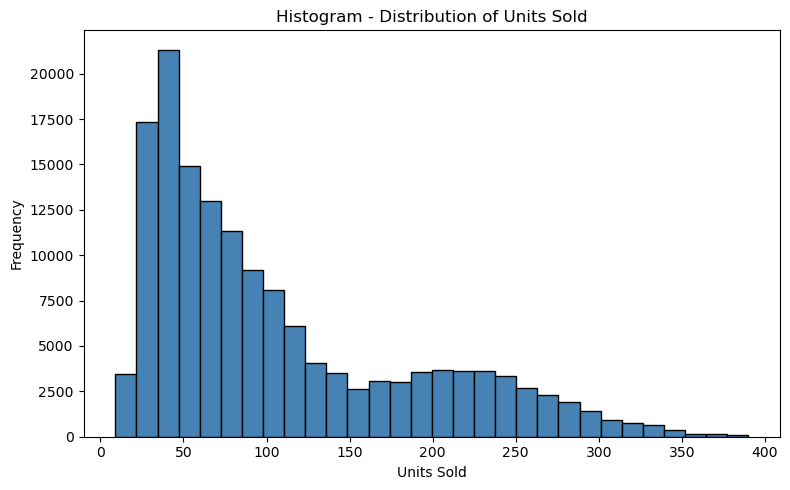

In [228]:
# Histogram - Distribution of Units Sold
plt.figure(figsize=(8, 5))
plt.hist(data['Units Sold'], bins=30, color='steelblue', edgecolor='black')
plt.title('Histogram - Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\Durgesh\AppData\Local\Temp\ipykernel_17320\3524998491.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(season_data, labels=seasons, patch_artist=True,


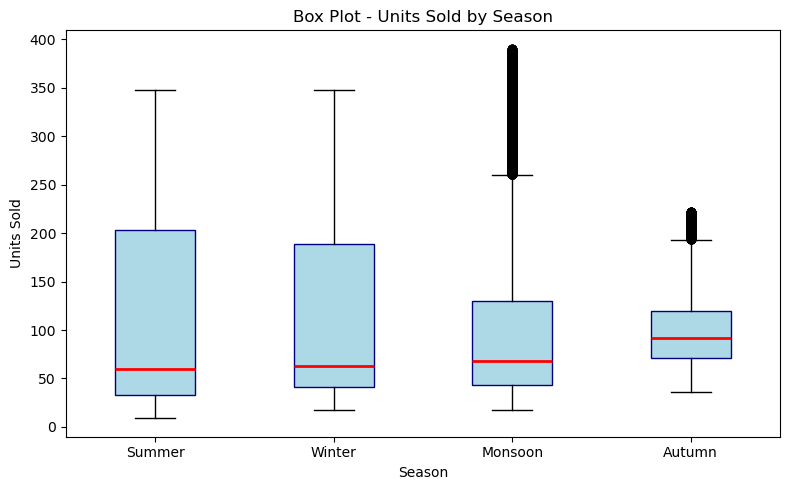

In [229]:
# Box Plot - Units Sold by Season
import pandas as pd
import matplotlib.pyplot as plt

original_data = pd.read_csv("retail_demand.csv").dropna()

plt.figure(figsize=(8, 5))
seasons = ['Summer', 'Winter', 'Monsoon', 'Autumn']
season_data = [original_data[original_data['Season'] == s]['Units Sold'].values for s in seasons]
plt.boxplot(season_data, labels=seasons, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Box Plot - Units Sold by Season')
plt.xlabel('Season')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

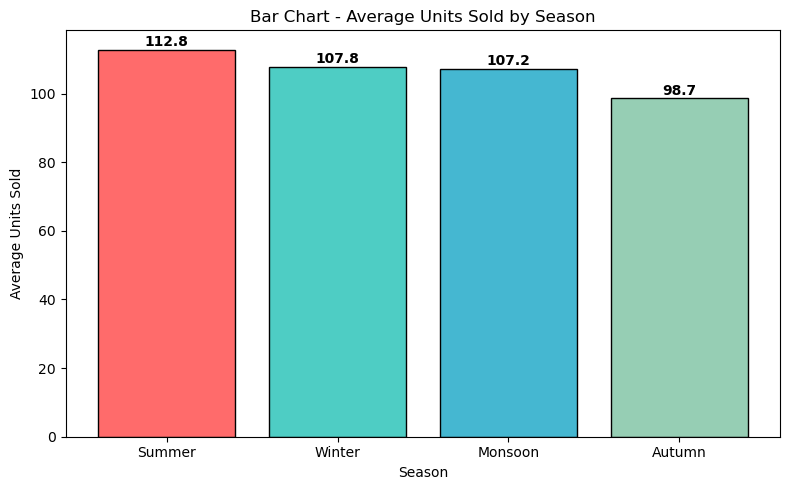

In [230]:
# Bar Chart - Average Units Sold by Season
plt.figure(figsize=(8, 5))
season_avg = original_data.groupby('Season')['Units Sold'].mean().reindex(seasons)
plt.bar(seasons, season_avg.values,
        color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'], edgecolor='black')
plt.title('Bar Chart - Average Units Sold by Season')
plt.xlabel('Season')
plt.ylabel('Average Units Sold')
for i, v in enumerate(season_avg.values):
    plt.text(i, v+1, f'{v:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

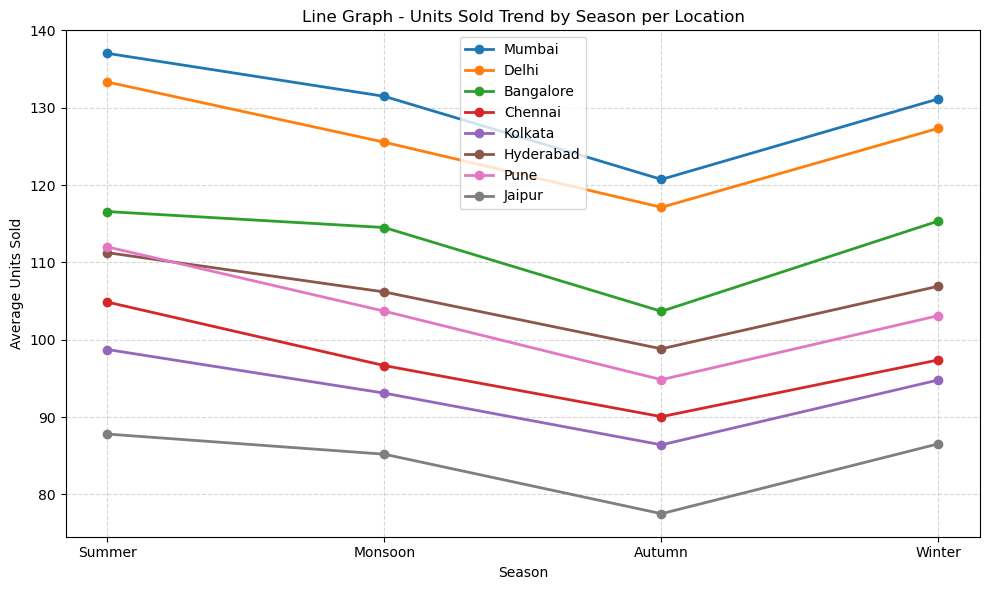

In [231]:
# Line Graph - Units Sold Trend by Season per Location
plt.figure(figsize=(10, 6))
locations = ['Mumbai','Delhi','Bangalore','Chennai','Kolkata','Hyderabad','Pune','Jaipur']
season_order = ['Summer', 'Monsoon', 'Autumn', 'Winter']

for location in locations:
    loc_df = original_data[original_data['Location'] == location]
    avg = loc_df.groupby('Season')['Units Sold'].mean().reindex(season_order)
    plt.plot(season_order, avg.values, marker='o', linewidth=2, label=location)

plt.title('Line Graph - Units Sold Trend by Season per Location')
plt.xlabel('Season')
plt.ylabel('Average Units Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()